# Financial Trading with Python, 2nd Edition

Cordell L. Tanny, CFA, FRM, FDP

**Chapter 13: Algorithmic Trading Strategies**

Notebook 13.1: A Cross-Sectional Bollinger Band Mean-Reversion System

Version: 1.0

Last revised: 2026-05-31

---

## Introduction

This notebook builds the first version of a complete trading system, not just a single signal. A mean-reversion idea sits at its core: when an exchange traded fund falls far enough below its recent average price, it is statistically stretched and tends to snap back. We turn that idea into a system by adding the parts a real strategy needs: which assets to watch, when to enter, when to exit, how much to allocate, and what to do when more opportunities appear than capital allows.

The build is deliberately staged across this chapter. This first iteration is the naive version, with the entry signal, position sizing, and capital allocation in place but no risk management at all. We run it end to end, then read its behaviour honestly, including its flaws. The most important flaw, a position that enters and never reverts and so is held open-ended, is left in on purpose. Seeing it in the results is what motivates the stop loss and time limit we add in the next iteration. The point of the chapter is the process of building and improving a system, not a finished money-printer handed over without its workings shown.

The strategy here produces one artifact: a sparse weights file, one row per date on which the held set of positions changes, fed to the backtest harness built earlier in this chapter. The harness runs the trades and scores the result, so this notebook stays focused on the signal and the portfolio logic.

This notebook covers:

- The universe of exchange traded funds and the entry-on-warmup rule that handles their staggered start dates
- Computing Bollinger bands per asset and the entry signal when price closes below the lower band
- The portfolio rules: a hard twenty percent cap per position, at most five positions, cash-drag sizing, and how the five most stretched names are chosen when entries compete for slots
- The hold-until-exit rule, where a position is held until its own price reverts to the band, with no rank-based rotation
- Building the sparse weights file and running it through the chapter backtest harness
- Reading the system's behaviour: how often it is fully invested, its holding periods, and the open-ended-hold flaw that the next iteration addresses

**Required Files:**
- `functions.py`
- `vectorbt_harness.py`

Please drag and drop them into the Colab instance.

## Section 1: Setup and the ETF Universe

Before anything else, the notebook prepares its own environment. It pulls the two helper modules and the package list from the book's repository, so nothing has to be uploaded into the session by hand.

Package versions live in one file in the repository rather than being written into each notebook. When a pinned version stops resolving, and eventually it will, the fix is a single commit instead of an edit to every notebook in the chapter.

This cell also sets where price data comes from. The `USE_SAVED_PRICES` flag controls it:

- `True`, the default, reads prices from files stored in the repository. Every figure printed in this chapter came from those exact files, so your results will match the book.
- `False` downloads fresh data from Yahoo Finance. The notebook still runs end to end, but your numbers will differ from the printed ones.

The reason for the saved files is worth stating. Yahoo recomputes its entire adjusted price history whenever a new dividend or split is recorded, so a series downloaded today is not the series downloaded last month, and across a twenty-year window those revisions compound. Without fixed data, a reader whose numbers differ has no way to tell whether the cause is data drift at the source or a mistake in their own setup.

In [23]:
# --- Environment and data source -------------------------------------------
# Fetches the helper modules and the package list from the book repository,
# installs, and reports what actually landed. Nothing needs uploading by hand.

import os, sys, subprocess, importlib

# True  : read prices from the saved files, results match the book
# False : download fresh from Yahoo, results will differ
USE_SAVED_PRICES = True

REPO_RAW = ('https://raw.githubusercontent.com/PacktPublishing/'
            'Hands-on-Financial-Trading-with-Python-Second-Edition/main')
SCRIPTS_URL = f'{REPO_RAW}/FINAL/python_scripts'
DATA_URL    = f'{REPO_RAW}/FINAL/chapter13/data_files'
REQS_URL    = f'{REPO_RAW}/FINAL'

# Versions this chapter was written against. Used only for the report below.
TESTED = {'python': '3.13', 'numpy': '2.1.3', 'pandas': '2.2.3',
          'vectorbt': '0.28.5', 'pyarrow': '18.1.0', 'yfinance': '0.2.66'}


def fetch(fname, url_base):
    """Download a file into the session if it is not already there."""
    if os.path.exists(fname):
        print(f'  using local {fname}')
        return fname
    subprocess.run(['wget', '-q', f'{url_base}/{fname}'])
    if not os.path.exists(fname):
        raise FileNotFoundError(f'Could not fetch {fname} from {url_base}')
    print(f'  fetched {fname}')
    return fname


def fetch_data_file(fname):
    """Return a local path to a saved data file, downloading it once if needed."""
    return fetch(fname, DATA_URL)


# A pinned package with no wheel for your Python does not fail cleanly: pip
# tries to build from source and the runtime usually dies first. Checking here
# turns that into a readable message.
PY = f'{sys.version_info.major}.{sys.version_info.minor}'
if PY != TESTED['python']:
    print(f'NOTE: this chapter was tested on Python {TESTED["python"]}; you are on {PY}.')
    print('      If the install below hangs, a pinned package has no wheel for '
          'your Python.\n')

fetch('requirements-ch13.txt', REQS_URL)
fetch('functions.py', SCRIPTS_URL)
fetch('vectorbt_harness.py', SCRIPTS_URL)

# No -q here. A silent install that fails leaves you debugging an ImportError
# several cells later instead of reading the actual error now.
print('\nInstalling...')
!pip install -r requirements-ch13.txt 2>&1 | tail -6

print(f'\n{"package":<12}{"installed":<14}{"tested":<12}')
print('-' * 38)
print(f'{"python":<12}{PY + "." + str(sys.version_info.micro):<14}{TESTED["python"]:<12}')
for pkg in ['numpy', 'pandas', 'pyarrow', 'vectorbt', 'numba', 'yfinance']:
    try:
        v = importlib.import_module(pkg).__version__
    except Exception:
        v = 'not installed'
    flag = '' if TESTED.get(pkg) in (None, v) else '  <- differs'
    print(f'{pkg:<12}{v:<14}{TESTED.get(pkg, "-"):<12}{flag}')

print(f'\nUSE_SAVED_PRICES = {USE_SAVED_PRICES}'
      f'  ({"saved files, results match the book" if USE_SAVED_PRICES else "live download, results will differ"})')

  using local requirements-ch13.txt
  using local functions.py
  using local vectorbt_harness.py

Installing...

package     installed     tested      
--------------------------------------
python      3.13.15       3.13        
numpy       2.1.3         2.1.3       
pandas      2.2.3         2.2.3       
pyarrow     18.1.0        18.1.0      
vectorbt    0.28.5        0.28.5      
numba       0.61.2        -           
yfinance    0.2.66        0.2.66      

USE_SAVED_PRICES = True  (saved files, results match the book)


The system trades a fixed list of fifty exchange traded funds spanning equity styles, sectors, regions, precious metals, commodities, and one high-yield credit fund. Government and investment-grade bond funds are left out on purpose, since the goal is to see how mean reversion behaves across risk assets rather than to build a balanced portfolio. The list is deliberately varied so the cross-sectional ranking has genuinely different candidates to choose among on any given day.

These funds did not all begin trading at the same time. Some of the newer thematic funds came to market only in the last several years, which would normally force an awkward choice between starting the whole backtest late or fabricating history that never existed. We avoid both. Each fund enters the eligible universe only once it has enough price history to compute its band, and before that it is simply excluded rather than backfilled. The eligible set therefore grows over time, starting small in the early years and filling out as more funds clear their warmup. This handles the staggered start dates natively and sidesteps survivorship bias without requiring a shared start date.

Every parameter that the later sensitivity tests will vary is collected at the top of the notebook in one place, so a single edit reruns the whole system at a different setting. The two that matter most are the band lookback and the entry sigma, the number of standard deviations below the moving average that defines a stretched price.

In [24]:
# --- Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
from functions import calculate_performance_metrics

warnings.filterwarnings('ignore')
sns.set_theme()
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)

# --- Parameters (centralized: edit here to rerun the whole system) ---
LOOKBACK   = 20      # band moving-average and std window, in trading days
ENTRY_SIGMA = 3.0    # standard deviations below the SMA for an entry signal
EXIT_BAND  = 'mid'   # exit target: 'mid' (the SMA) or 'upper' (SMA + sigma*std)
MAX_POSITIONS = 5    # at most this many concurrent positions
POSITION_CAP  = 0.20 # hard cap of capital per position (5 x 0.20 = fully invested)
WARMUP_BUFFER = 0    # extra days beyond LOOKBACK before an asset is eligible

START_DATE = '2007-01-01'   # earliest data pull; eligibility grows from here
END_DATE   = '2026-05-31'

# --- The ETF universe: 50 funds, varied on purpose ---
UNIVERSE = [
    # Equity: broad, style, sector, thematic
    'QQQ', 'VTI', 'VYM', 'IWM', 'SMDV', 'SPYG', 'IWF', 'VO', 'VBR', 'VOE',
    'SPGP', 'REGL', 'IWV', 'XLF', 'XLE', 'XLK', 'XLV', 'XLY', 'XLI', 'XLP',
    'XLU', 'XLC', 'SOXX', 'MOAT', 'ARKK', 'ARKG', 'ARKW', 'SDY', 'USMV', 'HDV',
    'DIA', 'FDN', 'VIG', 'FPX', 'ITB', 'ITA', 'DES', 'XMLV', 'SPY', 'QTUM',
    # High yield credit
    'HYG',
    # Metals, commodities, currency, miners
    'GLD', 'SLV', 'DBC', 'USO', 'PICK', 'UUP', 'GDX', 'GDXJ', 'DBA',
]

print(f"Universe size: {len(UNIVERSE)} ETFs")
print(f"Band: {LOOKBACK}-day SMA +/- {ENTRY_SIGMA} std of price")
print(f"Exit target: {EXIT_BAND} band | Max positions: {MAX_POSITIONS} | Cap: {POSITION_CAP:.0%}")
print(f"\nUniverse:\n{UNIVERSE}")

Universe size: 50 ETFs
Band: 20-day SMA +/- 3.0 std of price
Exit target: mid band | Max positions: 5 | Cap: 20%

Universe:
['QQQ', 'VTI', 'VYM', 'IWM', 'SMDV', 'SPYG', 'IWF', 'VO', 'VBR', 'VOE', 'SPGP', 'REGL', 'IWV', 'XLF', 'XLE', 'XLK', 'XLV', 'XLY', 'XLI', 'XLP', 'XLU', 'XLC', 'SOXX', 'MOAT', 'ARKK', 'ARKG', 'ARKW', 'SDY', 'USMV', 'HDV', 'DIA', 'FDN', 'VIG', 'FPX', 'ITB', 'ITA', 'DES', 'XMLV', 'SPY', 'QTUM', 'HYG', 'GLD', 'SLV', 'DBC', 'USO', 'PICK', 'UUP', 'GDX', 'GDXJ', 'DBA']


The output confirms the fifty funds loaded in the order listed, with the band, exit, and sizing parameters echoed back so every run carries a visible record of its settings. The default configuration shown here is the conservative one: a twenty-day band, an entry only when price falls a full three standard deviations below its average, a mid-band exit target, and at most five positions at twenty percent each. The three-sigma entry is intentionally strict, so signals are rare and the system spends much of its time only partially invested, which is one of the behaviours we want to observe rather than hide.

With the universe and parameters fixed, the next step is to pull the price history and turn each fund's prices into its Bollinger band, the moving average and the upper and lower bounds that define when a price is stretched.

## Section 2: Downloading Prices and Computing the Bands

We load dividend-adjusted daily closes for the whole universe at once, from the saved file or from a live download depending on the flag set earlier. The saved file holds the same frame yfinance returns, every price field included, so everything downstream of this cell is identical either way. As with the harness, the adjusted close folds in splits and dividends so the price series is continuous through corporate actions, and any fund that did not yet exist on a given date simply has no price there, which is exactly the missing-data pattern the entry-on-warmup rule relies on.

The band for each fund is built from its own price history alone. The middle of the band is the twenty-day simple moving average of price. The upper and lower edges sit a fixed number of standard deviations above and below that average, using the standard deviation of price over the same twenty-day window. Two points of discipline matter here. The standard deviation is computed on price, not on returns, because the band measures how far the current price sits from its recent typical level in that price's own units. And both the average and the standard deviation use only data through the prior close, so the band a price is compared against never contains the price it is being tested for. That shift by one day is what keeps the signal free of lookahead, and we verify it explicitly in a later cell.

In [25]:
# --- Load adjusted daily closes for the universe ---
# Both branches produce the same frame: the full yfinance OHLCV panel with
# a two-level column index. Everything below this point is unchanged.
if USE_SAVED_PRICES:
    raw = pd.read_parquet(fetch_data_file('ch13_nb01_signal_prices.parquet'))
else:
    raw = yf.download(UNIVERSE, start=START_DATE, end=END_DATE, auto_adjust=True)
prices = raw['Close'].copy()

# Keep the universe column order (yfinance returns them alphabetically).
prices = prices[[t for t in UNIVERSE if t in prices.columns]]

# --- Compute the band components per asset ---
# All three use data through the PRIOR close (shift by 1) so the band a price
# is tested against never includes that same day's price. This is the
# lookahead guard; we spot-check it in Section 3.
sma = prices.rolling(LOOKBACK).mean().shift(1)
std = prices.rolling(LOOKBACK).std().shift(1)

lower_band = sma - ENTRY_SIGMA * std
upper_band = sma + ENTRY_SIGMA * std
# Mid band is just the SMA; named here for clarity at the exit stage.
mid_band = sma

print(f"Price matrix: {prices.shape[0]} trading days, {prices.shape[1]} assets")
print(f"Date range:   {prices.index.min().date()} to {prices.index.max().date()}")
print(f"\nFirst valid band date per asset (shows staggered warmup):")
first_valid = lower_band.notna().idxmax()
first_valid = first_valid.sort_values()
print(first_valid.to_string())

  using local ch13_nb01_signal_prices.parquet
Price matrix: 4882 trading days, 50 assets
Date range:   2007-01-03 to 2026-05-29

First valid band date per asset (shows staggered warmup):
Ticker
QQQ    2007-02-01
DIA    2007-02-01
FPX    2007-02-01
ITB    2007-02-01
SDY    2007-02-01
ITA    2007-02-01
DES    2007-02-01
SPY    2007-02-01
GLD    2007-02-01
SOXX   2007-02-01
SLV    2007-02-01
XLU    2007-02-01
XLP    2007-02-01
XLI    2007-02-01
XLY    2007-02-01
FDN    2007-02-01
XLV    2007-02-01
XLE    2007-02-01
XLF    2007-02-01
IWV    2007-02-01
DBC    2007-02-01
USO    2007-02-01
VOE    2007-02-01
VBR    2007-02-01
VO     2007-02-01
IWF    2007-02-01
SPYG   2007-02-01
GDX    2007-02-01
IWM    2007-02-01
VYM    2007-02-01
VTI    2007-02-01
XLK    2007-02-01
VIG    2007-02-01
DBA    2007-02-05
UUP    2007-03-29
HYG    2007-05-09
GDXJ   2009-12-10
HDV    2011-04-29
SPGP   2011-07-15
USMV   2011-11-17
PICK   2012-03-02
MOAT   2012-05-23
XMLV   2013-03-18
ARKW   2014-10-28
ARKG   2014-12

The download returned all fifty funds over roughly nineteen years, and the first-valid-band dates show exactly the staggered entry the system is built to handle. Thirty-three funds have a usable band by the start of February 2007, twenty trading days after the data begins, which is the warmup the twenty-day window requires. From there the universe fills out in waves: GDXJ joins at the end of 2009, a cluster of low-volatility and moat funds arrives in 2011 and 2012, the ARK thematic funds appear in late 2014, and XLC and QTUM are the last to qualify in mid and late 2018. Until each of those dates the fund contributes no signal and is simply absent from the candidate pool, rather than being backfilled with invented history.

This is the entry-on-warmup rule working as intended, and it has a consequence worth keeping in mind when reading later results. The system has only about thirty-three names to choose from in its early years and the full fifty only from late 2018 onward, so the breadth of the cross-sectional ranking widens over time. A scarcity of signals in the early period is therefore expected behaviour, not a defect.

With the bands in place, we can now generate the entry signal: the daily test of whether each fund has closed below its lower band, and the stretch score that ranks how far below it sits.

## Section 3: The Entry Signal and the Stretch Score

The entry test is one comparison: has the fund closed below its lower band today? Because the band was built from data through the prior close, comparing today's close against it uses no same-day information in the band itself, which is the lookahead discipline we set up in the previous section and verify in a moment.

A simple yes or no is not enough, though, because on a turbulent day more than five funds can breach their lower bands at once, and the system can hold only five positions. We need a way to rank competing entries. For that we compute a stretch score: how many standard deviations below its moving average each fund has closed. A fund three and a half standard deviations below its average is more stretched, and a stronger mean-reversion candidate, than one barely past the three-sigma line. The score is the z-score of price against the same shifted average and standard deviation used for the band, so a more negative score means more stretched. When entries compete for a limited number of open slots, the most negative scores win.

We also run a deliberate lookahead spot-check here. We pick one fund and one date and recompute its band by hand from the twenty prior closes, then confirm it matches the shifted band used by the signal. This is the manual audit the chapter insists on for any rule that could hide a same-bar leak.

In [26]:
# --- Entry signal: did the close fall below the lower band? ---
below_lower = prices < lower_band

# --- Stretch score: z-score of price vs the shifted band stats ---
# More negative = further below the average = more stretched. Used only to
# rank competing entries when more than MAX_POSITIONS funds breach at once.
stretch = (prices - sma) / std

# --- Lookahead spot-check ---
# Recompute one band value by hand from the 20 closes PRIOR to a test date and
# confirm it equals the shifted SMA the signal uses. If these match, the band
# on a given day contains no information from that day.
test_ticker = 'SPY'
test_date = prices.index[300]                      # an arbitrary in-sample date
loc = prices.index.get_loc(test_date)

manual_window = prices[test_ticker].iloc[loc - LOOKBACK:loc]   # 20 prior closes
manual_sma = manual_window.mean()
used_sma = sma.loc[test_date, test_ticker]

print(f"Lookahead spot-check on {test_ticker} at {test_date.date()}:")
print(f"  Manual SMA of the 20 prior closes: {manual_sma:.4f}")
print(f"  SMA used by the signal (shifted):  {used_sma:.4f}")
print(f"  Match: {np.isclose(manual_sma, used_sma)}")

print(f"\nTotal lower-band breaches across all assets/days: {int(below_lower.sum().sum())}")
print(f"Days with at least one breach: {int(below_lower.any(axis=1).sum())}")
print(f"Days with MORE than {MAX_POSITIONS} simultaneous breaches: "
      f"{int((below_lower.sum(axis=1) > MAX_POSITIONS).sum())}")

Lookahead spot-check on SPY at 2008-03-13:
  Manual SMA of the 20 prior closes: 95.6646
  SMA used by the signal (shifted):  95.6646
  Match: True

Total lower-band breaches across all assets/days: 3919
Days with at least one breach: 874
Days with MORE than 5 simultaneous breaches: 182


The spot-check confirms the discipline we care about most. Recomputing SPY's average by hand from the twenty closes before March 13, 2008 gives exactly the value the signal used, which means the band a price is tested against contains no information from the day being tested. The signal is free of same-bar lookahead.

The breach counts give a first sense of how the strict three-sigma entry behaves across the whole universe and history. Lower-band breaches happen 3,919 times in total, spread across 874 distinct trading days, so on most days at least one fund somewhere in the universe is stretched. On 182 of those days more than five funds breach at once, which is when the system genuinely has to arbitrate: more candidates than open slots, and the stretch score decides which five are most extended. That is roughly four percent of all trading days, infrequent but far from negligible, and it confirms the ranking is doing real work rather than sitting idle.

Before turning signals into positions, it helps to see what the band actually looks like against a real price series. The chart below shows one fund, SPY, with its moving average and its upper and lower bands. The full history in the upper panel gives the overall picture, and because nineteen years compresses the bands into a narrow ribbon, the lower panel zooms into a single turbulent year where the structure is legible and the lower-band breaches that trigger entries are visible as the points where price dips beneath the lower line.

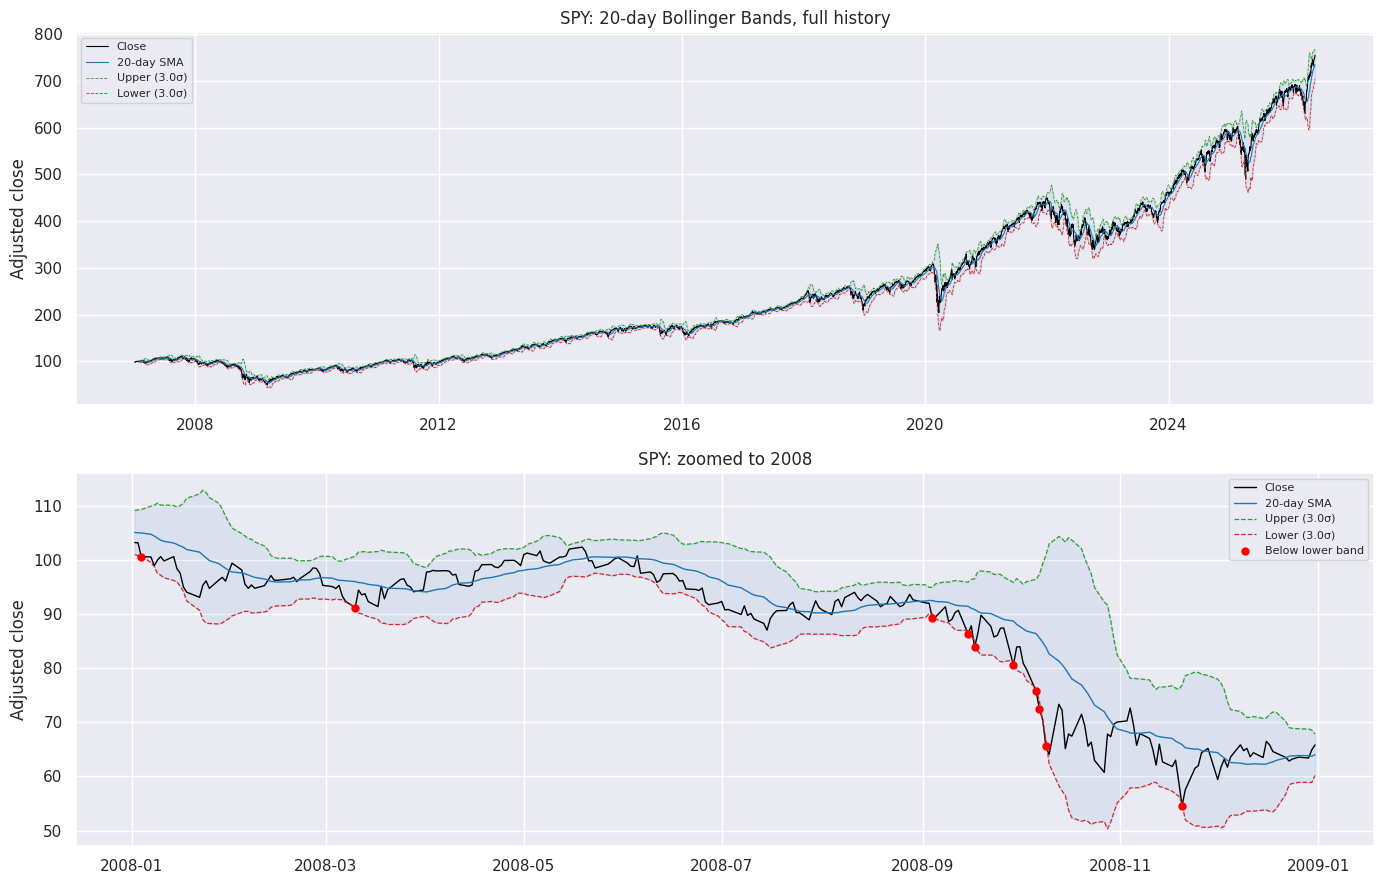

In [27]:
# --- Visualize the band for one ticker ---
plot_ticker = 'SPY'
zoom_year = '2008'   # a volatile stretch where breaches are easy to see

fig, (ax_full, ax_zoom) = plt.subplots(2, 1, figsize=(14, 9))

# Top panel: full history
ax_full.plot(prices.index, prices[plot_ticker], color='black', lw=0.8, label='Close')
ax_full.plot(sma.index, sma[plot_ticker], color='tab:blue', lw=0.8, label=f'{LOOKBACK}-day SMA')
ax_full.plot(upper_band.index, upper_band[plot_ticker], color='tab:green', lw=0.6,
             ls='--', label=f'Upper ({ENTRY_SIGMA}σ)')
ax_full.plot(lower_band.index, lower_band[plot_ticker], color='tab:red', lw=0.6,
             ls='--', label=f'Lower ({ENTRY_SIGMA}σ)')
ax_full.fill_between(prices.index, lower_band[plot_ticker], upper_band[plot_ticker],
                     color='tab:blue', alpha=0.08)
ax_full.set_title(f'{plot_ticker}: {LOOKBACK}-day Bollinger Bands, full history')
ax_full.set_ylabel('Adjusted close')
ax_full.legend(loc='upper left', fontsize=8)

# Bottom panel: one zoomed year
mask = (prices.index >= f'{zoom_year}-01-01') & (prices.index <= f'{zoom_year}-12-31')
px_z = prices[plot_ticker][mask]
ax_zoom.plot(px_z.index, px_z, color='black', lw=1.0, label='Close')
ax_zoom.plot(sma[plot_ticker][mask].index, sma[plot_ticker][mask], color='tab:blue', lw=1.0, label=f'{LOOKBACK}-day SMA')
ax_zoom.plot(upper_band[plot_ticker][mask].index, upper_band[plot_ticker][mask], color='tab:green', lw=0.9, ls='--', label=f'Upper ({ENTRY_SIGMA}σ)')
ax_zoom.plot(lower_band[plot_ticker][mask].index, lower_band[plot_ticker][mask], color='tab:red', lw=0.9, ls='--', label=f'Lower ({ENTRY_SIGMA}σ)')
ax_zoom.fill_between(px_z.index, lower_band[plot_ticker][mask], upper_band[plot_ticker][mask],
                     color='tab:blue', alpha=0.08)

# Mark the days price closed below the lower band (entry signals).
breach_days = px_z.index[px_z < lower_band[plot_ticker][mask]]
ax_zoom.scatter(breach_days, px_z[breach_days], color='red', s=25, zorder=5,
                label='Below lower band')

ax_zoom.set_title(f'{plot_ticker}: zoomed to {zoom_year}')
ax_zoom.set_ylabel('Adjusted close')
ax_zoom.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## Section 4: Tracking Positions Day by Day

The entry signal and the stretch score are vectorized, computed for the whole universe and history at once, but the held set cannot be. Whether a fund is a valid entry today depends on whether it is already held today, and whether a slot is open depends on which positions exited today, so the portfolio state on each day depends on the day before it. This is the part of the system that has to be walked forward one day at a time.

The loop carries one piece of state: the set of funds currently held, each with the band it must reach to exit. On each day, in order, it first checks the held funds and sells any whose price has reverted to its exit band, freeing those slots. It then looks at every fund below its lower band that is not already held, ranks them by stretch score so the most extended come first, and fills the open slots up to the maximum of five. A fund that is below its band but does not get a slot stays eligible on following days, on deck, until a slot opens or it rises back above the band. A held fund is never bought again; only its exit band closes it.

We record the held set on every day, then keep only the days on which it changed. That gives the sparse, event-driven weights the harness expects: a row whenever a position opens or closes, nothing on the days in between.

In [28]:
# --- Stateful position tracking, one day at a time ---
# State carried forward: held = {ticker: exit_level_series_key}. We only need
# to know which exit band applies; the level is looked up from mid/upper_band.

# Exit band lookup per the EXIT_BAND parameter.
exit_band = mid_band if EXIT_BAND == 'mid' else upper_band

dates = prices.index
held = {}                      # ticker -> True (the exit band is shared by all)
held_record = {}               # date -> set of held tickers (every day)

for today in dates:
    # ---- 1. EXITS (processed first) ----
    # Sell any held fund whose price has reverted to (or past) its exit band.
    to_exit = []
    for tk in held:
        px = prices.loc[today, tk]
        ex_level = exit_band.loc[today, tk]
        if pd.notna(px) and pd.notna(ex_level) and px >= ex_level:
            to_exit.append(tk)
    for tk in to_exit:
        del held[tk]

    # ---- 2. ENTRIES (fill freed/open slots) ----
    open_slots = MAX_POSITIONS - len(held)
    if open_slots > 0:
        # Candidates: below lower band today, not currently held, valid numbers.
        row_below = below_lower.loc[today]
        candidates = [tk for tk in UNIVERSE
                      if tk not in held
                      and bool(row_below.get(tk, False))
                      and pd.notna(stretch.loc[today, tk])]
        # Rank by stretch score, most negative (most stretched) first.
        candidates.sort(key=lambda tk: stretch.loc[today, tk])
        for tk in candidates[:open_slots]:
            held[tk] = True

    # ---- 3. RECORD the held set for today ----
    held_record[today] = set(held.keys())

# --- Summarize ---
held_counts = pd.Series({d: len(s) for d, s in held_record.items()})
print(f"Days simulated: {len(held_record)}")
print(f"Days fully invested (5 positions): {int((held_counts == MAX_POSITIONS).sum())}")
print(f"Days flat (0 positions): {int((held_counts == 0).sum())}")
print(f"Average positions held: {held_counts.mean():.2f}")
print(f"\nPosition count distribution:")
print(held_counts.value_counts().sort_index().to_string())

Days simulated: 4882
Days fully invested (5 positions): 1064
Days flat (0 positions): 1521
Average positions held: 2.05

Position count distribution:
0    1521
1    1022
2     501
3     425
4     349
5    1064


The distribution shows what a three-sigma entry does to capital deployment:

- Average positions held: 2.05 out of 5, so about 41% of capital is invested on a typical day and 59% sits in cash.
- Flat (zero positions): 1,521 days, roughly a third of the sample.
- Fully invested (5 positions): 1,064 days, about 22%, clustered in broad sell-offs when many funds breach at once.

The cash drag is a direct result of the three-sigma band. A three standard deviation breach is rare, so the portfolio is rarely full. We start at three sigma deliberately, to minimize false positives: a wider band means fewer but higher-conviction signals. This is the first place the parameter choice drives the whole system, and the sensitivity tests later will show how much loosening to two sigma changes it.

## Section 5: Building the Sparse Weights File

The daily record of held positions now becomes the weights file the harness consumes. Each held fund gets an equal twenty percent of capital, and when fewer than five are held the unallocated weight is simply absent, which the harness treats as cash. We convert the held set on each day into a row of weights, then keep only the days on which the held set changed, since those are the days a trade actually happens. A day where the same funds are held as the day before needs no row, because nothing was bought or sold. This is the sparse, event-driven form the harness expects, and it matches the convention we verified on the earlier strategy file: a row is a trade date, and the position drifts between rows.

In [29]:
# --- Convert the daily held record into a full daily weights frame ---
# Each held fund gets an equal share, capped at POSITION_CAP. With MAX_POSITIONS
# of 5 and a 0.20 cap, a full book is 100% invested; fewer names leave cash.
weights_daily = pd.DataFrame(0.0, index=dates, columns=UNIVERSE)
for today, names in held_record.items():
    if names:
        for tk in names:
            weights_daily.loc[today, tk] = POSITION_CAP

# --- Reduce to event-driven rows: keep only days the held set changed ---
# A trade happens only when today's weights differ from yesterday's. The first
# invested day is always a change (from all-cash). This produces the sparse file.
changed = (weights_daily != weights_daily.shift(1)).any(axis=1)
weights_sparse = weights_daily[changed].copy()

# Drop any all-zero rows at the very start before the first position opens, but
# keep a zero row that represents a genuine move back to all-cash (a real trade).
first_invest_idx = weights_daily.any(axis=1).idxmax()
weights_sparse = weights_sparse.loc[first_invest_idx:]

# --- Save for the harness ---
out_file = 'bollinger_I1_weights.csv'
weights_sparse.to_csv(out_file)

print(f"Daily weight rows:        {len(weights_daily)}")
print(f"Event-driven (trade) rows: {len(weights_sparse)}")
print(f"First trade date:         {weights_sparse.index.min().date()}")
print(f"Last trade date:          {weights_sparse.index.max().date()}")
print(f"Saved: {out_file}")
print(f"\nFirst 12 trade rows (nonzero columns only):")
for d, row in weights_sparse.head(12).iterrows():
    active = row[row != 0]
    print(f"  {d.date()}: {dict(active.round(2))}")

Daily weight rows:        4882
Event-driven (trade) rows: 922
First trade date:         2007-02-27
Last trade date:          2026-05-26
Saved: bollinger_I1_weights.csv

First 12 trade rows (nonzero columns only):
  2007-02-27: {'XLF': np.float64(0.2), 'XLV': np.float64(0.2), 'XLY': np.float64(0.2), 'DIA': np.float64(0.2), 'SPY': np.float64(0.2)}
  2007-03-20: {'XLF': np.float64(0.2), 'XLY': np.float64(0.2), 'DIA': np.float64(0.2)}
  2007-03-21: {}
  2007-03-30: {'DBA': np.float64(0.2)}
  2007-04-13: {}
  2007-04-16: {'UUP': np.float64(0.2)}
  2007-05-03: {}
  2007-05-24: {'XLU': np.float64(0.2), 'SOXX': np.float64(0.2)}
  2007-06-01: {'XLU': np.float64(0.2)}
  2007-06-07: {'XLF': np.float64(0.2), 'XLV': np.float64(0.2), 'XLU': np.float64(0.2), 'SDY': np.float64(0.2), 'HYG': np.float64(0.2)}
  2007-06-15: {'XLV': np.float64(0.2), 'XLU': np.float64(0.2), 'SDY': np.float64(0.2), 'HYG': np.float64(0.2)}
  2007-06-20: {'XLV': np.float64(0.2), 'XLU': np.float64(0.2), 'SDY': np.float64(0.2), 

The 4,882 daily rows collapse to 922 trade rows, the days the held set actually changed. Empty rows are real trades too: a move back to all-cash when the last position exits. The first trade row opens five sector and broad-equity funds at once on February 27, 2007, a day a market-wide pullback pushed many names below their bands simultaneously, which is the cluster behaviour the three-sigma entry produces in broad sell-offs.

This file is the strategy's entire output. From here the harness takes over: it downloads prices for these tickers, runs the trades at each row, and scores the result.

## Section 6: Backtesting the System

The weights file is the entire interface between this strategy and the backtest. The chapter backtest harness, built earlier and imported here as a module, does the rest: it takes adjusted prices for the tickers in the file, aligns them, runs the trades at each dated row with whole shares and realistic costs, and scores the result against a benchmark on monthly returns. Because every strategy in the chapter calls the same harness, the numbers here are directly comparable to the other systems we build.

We pass SPY as the benchmark, used for reference only. The system trades a small, often partly-invested book of mean-reversion positions, so we do not expect it to match a fully-invested equity index on total return. What matters is the risk-adjusted picture: the profit factor, the win rate, and the drawdown profile relative to how much capital is actually at work.

When the saved-price flag is on we hand the harness two frames: the prices for the traded tickers and the benchmark prices. Both are needed. The benchmark's first available day helps set where the backtest window starts, so leaving the benchmark to a live download would let the comparison window move even with the strategy prices fixed. With the flag off, both arrive as None and the harness downloads them itself.

In [30]:
# --- Backtest via the chapter harness ---
# The harness is a module (vectorbt_harness.py) fetched into the session above.
# It loads the weights file, aligns prices, runs the VectorBT portfolio with
# whole shares and costs, and scores against the benchmark.

from vectorbt_harness import run_backtest

if USE_SAVED_PRICES:
    # The saved frame covers a wider window than this strategy needs. The
    # harness trims it to the exact window implied by the weights file, so the
    # saved and live paths score the same period.
    bt_prices = pd.read_parquet(fetch_data_file('ch13_nb01_backtest_prices.parquet'))
    bm_prices = pd.read_parquet(
        fetch_data_file('ch13_nb01_benchmark_prices.parquet')).iloc[:, 0]
else:
    bt_prices = None    # None means the harness downloads, as it always did
    bm_prices = None

result = run_backtest(
    'bollinger_I1_weights.csv',
    benchmark='SPY',
    fees=0.0010,        # 10 bps commission on the run with costs applied
    slippage=0.0005,    # 5 bps slippage on the run with costs applied
    init_cash=10_000,
    periods_per_year=12,
    prices=bt_prices,
    bench_prices=bm_prices,
)

  using local ch13_nb01_backtest_prices.parquet
  using local ch13_nb01_benchmark_prices.parquet
Using saved prices (no download).
  Saved file covers:  2007-01-03 to 2026-06-29
  Window taken:       2007-02-27 to 2026-06-01  (4846 rows)
Using saved benchmark prices for SPY (no download).
Backtest start: 2007-02-27
Backtest end:   2026-06-01
Trading days:   4846
Trades in window: 922

Harness evaluation (monthly metrics)
                         Strategy No Cost Strategy w/ Costs SPY Buy & Hold
Total Return                      115.26%            38.36%        675.50%
Ann. Return (CAGR)                  4.03%             1.69%         11.13%
Ann. Volatility                    12.55%            12.43%         15.47%
Downside Deviation                  9.41%             9.61%         10.13%
Max Drawdown                      -32.97%           -35.55%        -50.78%
Max DD Duration (months)               71               122             52
Ulcer Index                        12.623         

The result is the naive system seen plainly. A few things stand out:

- Without transaction costs, the system returns 116% over the period against SPY's 675%, a 4.0% annual return versus 11.1%. It loses badly to a fully-invested index on total return, exactly as expected for a small, often partly-invested book.
- Costs hit hard: the costed return falls to 39%, a 1.7% annual return. A 10 bps commission and 5 bps slippage should not erase that much unless turnover is high, and it is. The 922 trade rows include many fast round trips, where a mid-band exit closes a position a day or two after entry.
- The risk profile is the redeeming side. The win rate of 68.5% slightly beats SPY, and the max drawdown of -33% is far shallower than SPY's -51%. This is a high-hit-rate system with small average wins, carrying a lot of cash.

The costed column is the one to anchor on, since it is what a real account would have earned. The turnover it exposes, and the open-ended holds we look at next, are the specific weaknesses the later iterations are built to address. The mid-band versus upper-band exit test and the time limits in Iteration 2 both bear directly on this cost drag.

## Section 7: Seeing the Trades

The metric table is a verdict without a story. To understand how the system actually behaves, we look at the trades themselves: how long positions are held, which ones worked, and which ones hurt. The harness exposes every round-trip trade from the portfolio, so we can read them directly.

We start with the holding-period distribution and a sample of the trade record, then trace two individual trades on their price charts: one that worked exactly as intended, and one that shows the cost of having no risk management. The contrast between them is the argument for the next iteration.

In [31]:
# --- The trade record ---
trades = result.pf_no_cost.trades.records_readable.copy()
trades['Ticker'] = trades['Column'].apply(lambda c: c[0] if isinstance(c, tuple) else c)
trades['Hold Days'] = (pd.to_datetime(trades['Exit Timestamp'])
                       - pd.to_datetime(trades['Entry Timestamp'])).dt.days

print(f"Total round-trip trades: {len(trades)}")
print(f"Win rate (per trade):    {(trades['Return'] > 0).mean():.1%}")
print(f"Median holding period:   {trades['Hold Days'].median():.0f} calendar days")
print(f"Longest hold:            {trades['Hold Days'].max():.0f} calendar days")
print(f"\nHolding period distribution (calendar days):")
print(trades['Hold Days'].describe().round(1).to_string())

# A readable sample of the blotter.
sample_cols = ['Ticker', 'Entry Timestamp', 'Exit Timestamp', 'Hold Days', 'Return']
print(f"\nSample of trades (first 10):")
print(trades[sample_cols].head(10).to_string(index=False))

Total round-trip trades: 819
Win rate (per trade):    69.6%
Median holding period:   18 calendar days
Longest hold:            88 calendar days

Holding period distribution (calendar days):
count    819.0
mean      19.7
std       13.2
min        1.0
25%       10.0
50%       18.0
75%       25.0
max       88.0

Sample of trades (first 10):
Ticker Entry Timestamp Exit Timestamp  Hold Days    Return
   QQQ      2010-01-22     2010-02-16         25  0.003623
   QQQ      2011-11-21     2011-11-30          9  0.037726
   QQQ      2015-08-20     2015-09-11         22 -0.014102
   QQQ      2016-04-28     2016-05-20         22  0.001788
   VTI      2013-10-08     2013-10-10          2  0.021810
   VTI      2017-07-06     2017-07-12          6  0.014637
   VTI      2023-09-21     2023-10-10         19  0.007193
   VYM      2007-10-19     2007-11-29         41 -0.021889
   VYM      2008-11-20     2008-11-28          8  0.183795
   VYM      2009-01-20     2009-02-06         17  0.053913


Two trades tell the story of the system better than any summary. The first is VO, entered on November 20, 2008, at the depth of the financial crisis selloff. Price had been driven far below its lower band, the system bought, and within eight days it reverted to the mid band for a gain of about twenty-four percent. This is mean reversion working exactly as designed: a panic breach, a sharp snap back.

The second is XLE, entered on February 24, 2020, as the COVID crash began. The entry signal was the same, a close below the lower band, but the outcome was the opposite. Price kept falling for weeks while the system held on, because the only exit is a reversion to the mid band and there is no stop loss to cut the position. By the time XLE finally reverted in early April, the trade closed down about forty percent. The chart below traces both.

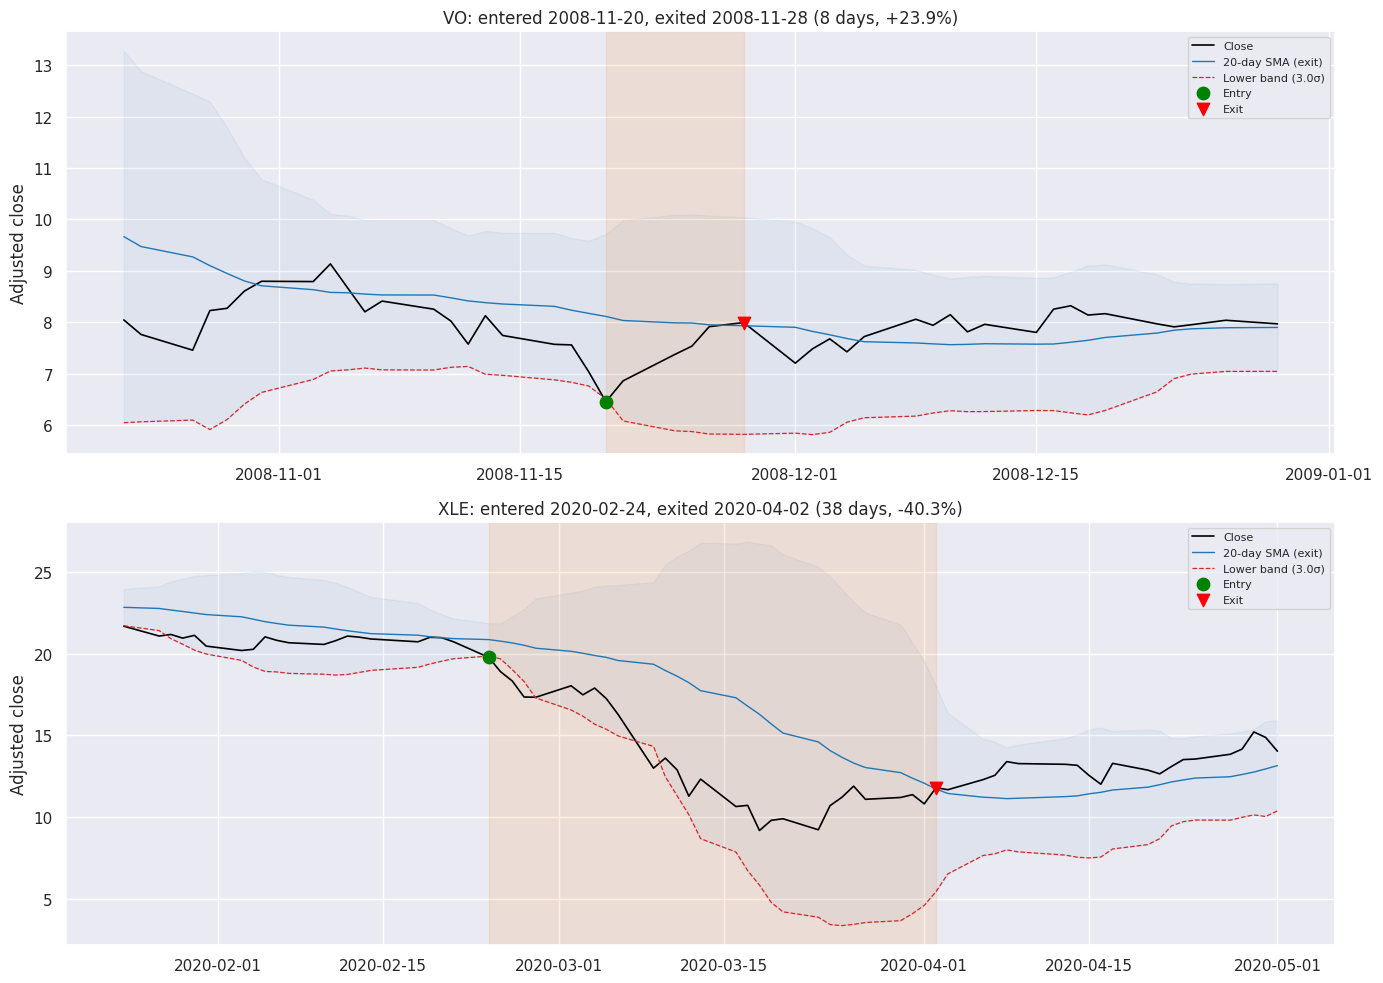

In [32]:
# --- Trace two trades on their price charts with the bands ---
def trace_trade(ax, ticker, entry_date, exit_date, pad=20):
    """Plot one ticker's price and bands around a trade, marking entry/exit."""
    entry = pd.Timestamp(entry_date)
    ex = pd.Timestamp(exit_date)
    lo = prices.index[prices.index.get_loc(entry) - pad]
    hi_loc = min(prices.index.get_loc(ex) + pad, len(prices.index) - 1)
    hi = prices.index[hi_loc]
    window = (prices.index >= lo) & (prices.index <= hi)

    px = prices[ticker][window]
    ax.plot(px.index, px, color='black', lw=1.2, label='Close')
    ax.plot(px.index, sma[ticker][window], color='tab:blue', lw=1.0, label=f'{LOOKBACK}-day SMA (exit)')
    ax.plot(px.index, lower_band[ticker][window], color='tab:red', lw=0.9, ls='--', label=f'Lower band ({ENTRY_SIGMA}σ)')
    ax.fill_between(px.index, lower_band[ticker][window], upper_band[ticker][window],
                    color='tab:blue', alpha=0.06)

    # Shade the holding period and mark entry/exit.
    ax.axvspan(entry, ex, color='tab:orange', alpha=0.12)
    ax.scatter([entry], [prices.loc[entry, ticker]], color='green', s=80, zorder=5, label='Entry')
    ax.scatter([ex], [prices.loc[ex, ticker]], color='red', s=80, marker='v', zorder=5, label='Exit')

    held_days = (ex - entry).days
    ret = prices.loc[ex, ticker] / prices.loc[entry, ticker] - 1
    ax.set_title(f'{ticker}: entered {entry.date()}, exited {ex.date()} '
                 f'({held_days} days, {ret:+.1%})')
    ax.legend(loc='best', fontsize=8)
    ax.set_ylabel('Adjusted close')

fig, (ax_win, ax_loss) = plt.subplots(2, 1, figsize=(14, 10))
trace_trade(ax_win, 'VO', '2008-11-20', '2008-11-28')
trace_trade(ax_loss, 'XLE', '2020-02-24', '2020-04-02')
plt.tight_layout()
plt.show()

The two panels make the system's central weakness visible. In both trades the entry rule fired identically: price closed below the lower band, shown by the green marker near the lower line, and the position was opened. The exit rule was also identical: close the position when price reverts to the mid band, the blue line, shown by the red marker.

What differs is everything in between. VO reverted in eight days, a textbook mean-reversion snap back from a crisis-driven extreme. XLE kept falling for weeks after entry, dropping far below the band and staying there, because the system has no stop loss and no time limit. Its only way out is a reversion that, in this case, did not come until price had fallen another thirty percent. The position eventually closed at a loss of about forty percent.

Both trades obeyed the same rules. The difference in outcome was entirely a matter of what happened after entry, and the naive system has no mechanism to manage that. A losing position is simply held until it reverts, however far it falls and however long it takes. This is the flaw the next iteration addresses, with a stop loss to cap the downside on a position that keeps falling and a time limit to release capital from one that goes nowhere.

The painful holds are one source of weakness; turnover is the other. The system exits the moment price touches the mid band, and sometimes that happens a day or two after entry. A breach reverts almost immediately, the position closes for a small gain, and the system has paid the spread on both the entry and the exit for a trade it barely held. One or two of these is harmless. Hundreds of them, across 822 trades, are what drove the costed return so far below the uncosted one. The cell below isolates the fastest round trips to show where that cost comes from.

In [33]:
# --- Fast round trips: where the turnover cost comes from ---
fast = trades[trades['Hold Days'] <= 3].sort_values('Hold Days')

print(f"Trades held 3 calendar days or fewer: {len(fast)} of {len(trades)} "
      f"({len(fast)/len(trades):.0%})")
print(f"Average return on these fast trades: {fast['Return'].mean():.2%}")
print(f"Median return on these fast trades:  {fast['Return'].median():.2%}")
print(f"\nFastest round trips:")
cols = ['Ticker', 'Entry Timestamp', 'Exit Timestamp', 'Hold Days', 'Return']
print(fast[cols].head(12).to_string(index=False))

# Rough cost intuition: each round trip pays fees + slippage twice (in and out).
round_trip_cost = (0.0010 + 0.0005) * 2     # 15 bps each way, both directions
print(f"\nApproximate round-trip cost per trade: {round_trip_cost:.2%}")
print(f"On a 1-day trade returning under {round_trip_cost:.2%}, costs exceed the gain.")

Trades held 3 calendar days or fewer: 25 of 819 (3%)
Average return on these fast trades: 3.83%
Median return on these fast trades:  2.92%

Fastest round trips:
Ticker Entry Timestamp Exit Timestamp  Hold Days    Return
   XLP      2025-05-14     2025-05-15          1  0.020500
   XLP      2022-02-24     2022-02-25          1  0.032228
  ARKW      2022-11-09     2022-11-10          1  0.136329
   UUP      2007-06-20     2007-06-21          1  0.040630
   DBA      2024-08-01     2024-08-02          1  0.001290
  ARKW      2022-11-09     2022-11-11          2  0.218535
   XLI      2021-01-04     2021-01-06          2  0.033908
   VTI      2013-10-08     2013-10-10          2  0.021810
   USO      2017-01-10     2017-01-12          2  0.042457
   UUP      2016-02-03     2016-02-05          2 -0.002378
  MOAT      2013-10-08     2013-10-10          2  0.023649
   IWV      2013-10-08     2013-10-10          2  0.022432

Approximate round-trip cost per trade: 0.30%
On a 1-day trade returning

The fast round trips turn out not to be the problem. Only 24 trades, about three percent, are held three days or fewer, and they average a four percent return, far above the 0.30 percent it costs to round-trip a position. Cutting them would change little.

The cost drag is broader than that. The system makes 822 trades, each paying roughly 0.30 percent in commission and slippage to enter and exit, on a median holding period of eighteen days. The issue is not a few wasteful trades but the combination of many trades and a thin edge on each. The per-trade win is small, and a small edge does not survive a fixed toll levied 822 times and compounded. This is why the uncosted return of 116 percent falls to 39 percent once costs are applied: not because any single trade is bad, but because the system trades often for a modest edge, and costs scale with the number of trades.

This reframes what risk management needs to do in the next iteration. It is not only about cutting the deep losers like XLE. Holding good positions longer, through a higher exit band or a time structure that avoids re-entering the same names repeatedly, would lower the trade count and let more of the gross edge survive. The naive system trades too much for too little, and that, as much as the open losses, is what the iterations have to fix.

## Section 8: What Iteration 1 Tells Us

The naive system works as a mean-reversion engine and fails as a finished strategy, which is exactly what this iteration was meant to show. Pulling the results together:

- The signal is real. A 69 percent per-trade win rate and trades like VO confirm that a deep breach below the band tends to revert. The edge exists.
- The edge is thin and the system overtrades. Across 822 trades the per-trade gain is small, and a 0.30 percent round-trip cost repeated that many times cuts the uncosted 116 percent return down to 39 percent. Costs, not any single bad trade, are the largest drag.
- There is no downside management. A position is held until it reverts, however far it falls. XLE fell forty percent over thirty-eight days before it exited, with nothing to cut the loss or free the capital.
- Cash drag is structural. The three-sigma entry is rare, so the book averages two positions out of five and holds a large cash balance, which caps the upside against a fully invested benchmark.

None of these is a coding error; each is a design consequence we chose to leave in so it could be seen. Together they set the agenda for the next iteration. A stop loss addresses the XLE problem directly, cutting a position that keeps falling. A time limit releases capital from a position that goes nowhere. Both should also lower the trade count and let more of the gross edge survive costs. Iteration 2 adds these two risk controls and measures, on the same full metric set, whether disciplined risk management improves the system or simply trades one weakness for another.